# 던파 캐릭터 탐지 모델 개선 보고서 (v1 → v2)

**작성일**: 2026-06-13 | **환경**: RTX 5090 (32GB), PyTorch 2.11.0+cu128, Ultralytics YOLO11s 8.4.66

## 프로젝트 개요

던전앤파이터 게임 스크린샷에서 **캐릭터와 닉네임을 탐지**하는 객체 탐지 모델.

| 클래스 | ID | 정의 |
|---|---|---|
| `character` | 0 | 화면에 보이는 **모든 플레이어 캐릭터** (내 캐릭터 + 파티원) |
| `user_id` | 1 | 캐릭터 머리 위 닉네임 텍스트 영역 |

**구조 (A안)**: 내 캐릭터와 파티원은 시각적으로 구분이 불가능(같은 직업 스프라이트)하므로, 모델은 "모든 캐릭터 탐지"라는 시각적으로 명확한 과제만 풀고, **"내 캐릭터" 선정은 후처리**(user_id 박스 바로 아래의 character 선택)가 담당한다.

**학습 설정**: `yolo11s`, `imgsz=1280`, `batch=8`, max 80 epochs (patience 20).
- imgsz=1280인 이유: 가장 작은 객체인 user_id(원본 약 70×24px)가 640에서는 ~25×9px로 탐지 한계선에 걸리지만, 1280에서는 ~50×17px로 안전하게 보존된다.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path(r"C:\Users\park\Desktop\MINI_DATA_PROJECT")
V1 = ROOT / "runs/df_yolo11s_1280_e80"   # v1: 검수 전 라벨로 학습
V2 = ROOT / "runs/df_yolo11s_1280_v2"    # v2: 검수 반영 후 재학습

n_labeled = len(list((ROOT / "labeled").glob("*.json")))
n_sprites = len(list((ROOT / "DF_character_dataset").rglob("*.png")))
n_train = len(list((ROOT / "datasets/df/images/train").glob("*.jpg")))
n_synth = len(list((ROOT / "datasets/df/images/train").glob("synth_*.jpg")))
n_val = len(list((ROOT / "datasets/df/images/val").glob("*.jpg")))
print(f"라벨링 스크린샷  : {n_labeled}장 (labelme JSON, 43종 해상도)")
print(f"스프라이트       : {n_sprites}장 (17개 직업군, 알파 투명 PNG)")
print(f"train           : {n_train}장 = 실사 {n_train - n_synth} + 합성 {n_synth}")
print(f"val             : {n_val}장 (실사만, 합성 오염 없음)")

라벨링 스크린샷  : 907장 (labelme JSON, 43종 해상도)
스프라이트       : 7070장 (17개 직업군, 알파 투명 PNG)
train           : 2817장 = 실사 817 + 합성 2000
val             : 90장 (실사만, 합성 오염 없음)


## 1. v1의 학습 데이터

v1은 두 종류의 데이터로 학습했다 (train 2,817장 = 실사 817 + 합성 2,000 / val 90장, seed 42 고정 분할):

1. **실사 스크린샷 907장** — labelme로 라벨링된 실제 플레이 화면. `user_character` → `character`(0), `user_id`(1)로 매핑해 YOLO 형식으로 변환. 오라벨 1건(`eye`)은 변환 시 제외.
2. **합성 이미지 2,000장** — 아래 절차로 생성.

### 1.1 합성 데이터를 만든 이유와 방법

**한계**: 실사 907장만으로는 17개 직업군 × 다수의 眞 전직 × 아바타 조합이라는 캐릭터 외형 다양성을 커버할 수 없다. 보조 데이터로 직업별 단독 스프라이트 7,070장(`DF_character_dataset`)을 확보했지만, **배경 없는 단독 스프라이트를 그대로 탐지 학습에 넣으면 도메인 갭**(배경·이펙트·UI 부재) 때문에 효과가 없거나 해롭다.

**해법 — 합성(synthetic compositing)**: 실제 train 스크린샷을 배경으로 스프라이트를 붙여넣어 라벨을 자동 생성한다.

| 단계 | 내용 |
|---|---|
| 배경 | train 분할 실사 스크린샷에서 무작위 선택 (val에는 합성하지 않음 → 평가 오염 방지) |
| 개수 | 이미지당 스프라이트 1~4개 |
| 크기 | 실제 라벨의 character 박스 **높이 분포에서 샘플링** + ±15% 지터 (화면 속 실제 캐릭터 크기와 일치) |
| 증강 | 50% 좌우 반전, 밝기 0.8~1.15배 (장면에 자연스럽게 섞이도록) |
| 배치 | 기존 박스와 IoU < 0.25 회피, 우측 채팅창·하단 UI 영역 제외 |
| 라벨 | 합성 위치 = 박스 좌표 → 원본 라벨과 병합해 자동 생성 |

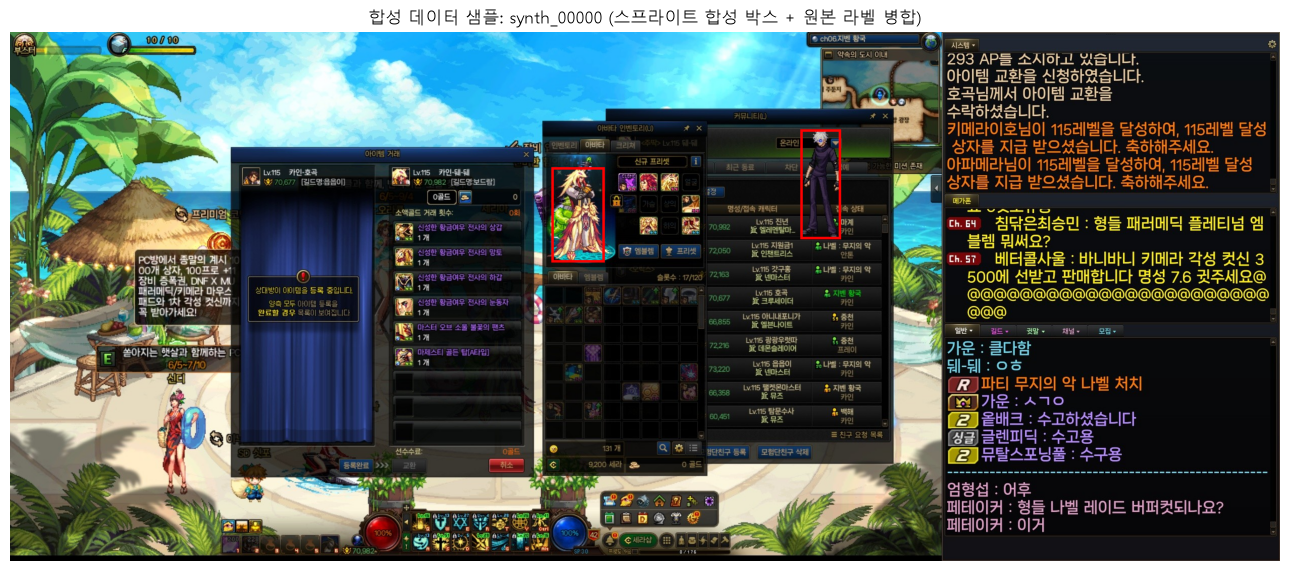

In [2]:
# 합성 샘플 확인 (빨강 = character, 청록 = user_id)
from PIL import Image, ImageDraw

name = "synth_00000"
im = Image.open(ROOT / f"datasets/df/images/train/{name}.jpg")
W, H = im.size
d = ImageDraw.Draw(im)
for line in (ROOT / f"datasets/df/labels/train/{name}.txt").read_text().splitlines():
    c, cx, cy, bw, bh = map(float, line.split())
    d.rectangle([(cx - bw/2)*W, (cy - bh/2)*H, (cx + bw/2)*W, (cy + bh/2)*H],
                outline="red" if c == 0 else "cyan", width=5)
plt.figure(figsize=(13, 6.5))
plt.imshow(im); plt.axis("off")
plt.title(f"합성 데이터 샘플: {name} (스프라이트 합성 박스 + 원본 라벨 병합)")
plt.tight_layout(); plt.show()

## 2. v1 학습 결과와 한계

v1은 33 epochs에서 조기 종료(best: epoch 13)했고, **전체 mAP50 0.856**을 기록했다. 그러나 클래스별로 보면 뚜렷한 약점이 있었다.

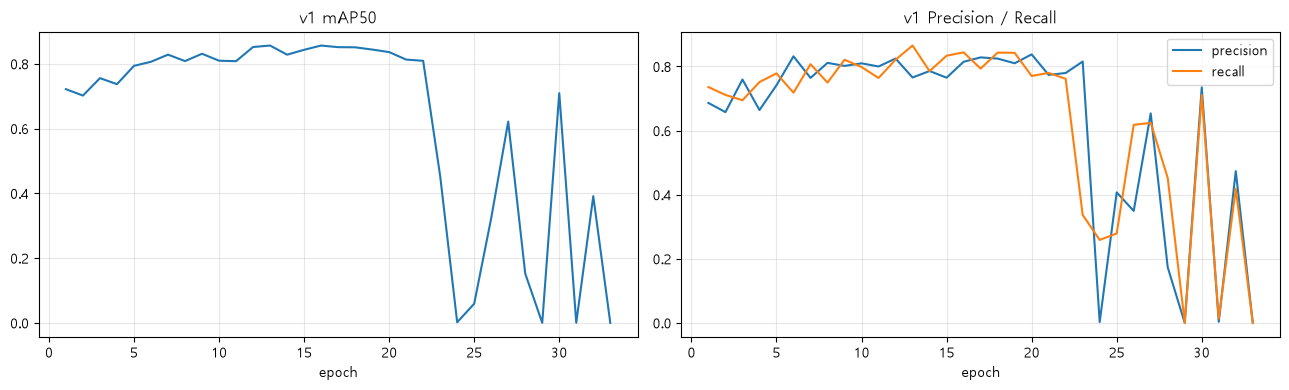

,Precision,Recall,mAP50,mAP50-95
전체,0.763,0.865,0.856,0.535
character,0.683,0.868,0.814,0.472
user_id,0.844,0.862,0.897,0.598


In [3]:
# v1 학습 곡선
v1_df = pd.read_csv(V1 / "results.csv")
v1_df.columns = v1_df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(v1_df["epoch"], v1_df["metrics/mAP50(B)"], color="tab:blue")
axes[0].set_title("v1 mAP50"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(v1_df["epoch"], v1_df["metrics/precision(B)"], label="precision")
axes[1].plot(v1_df["epoch"], v1_df["metrics/recall(B)"], label="recall")
axes[1].set_title("v1 Precision / Recall"); axes[1].set_xlabel("epoch")
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# 최종 검증 지표 (학습 종료 시 best.pt로 측정한 로그 값)
v1_final = pd.DataFrame({
    "Precision": [0.763, 0.683, 0.844],
    "Recall":    [0.865, 0.868, 0.862],
    "mAP50":     [0.856, 0.814, 0.897],
    "mAP50-95":  [0.535, 0.472, 0.598],
}, index=["전체", "character", "user_id"])
v1_final

### 2.1 한계 진단 — character Precision 0.683의 정체

`user_id`는 mAP50 0.897로 양호했지만 **character의 precision이 0.683**으로 유난히 낮았다. 원인은 모델이 아니라 **라벨에 있었다**:

- 원래 라벨링 정책이 "내 캐릭터(user_character)만 박스"였기 때문에, 화면에 함께 있는 **파티원·다른 유저 캐릭터는 라벨 없이 배경 취급**되고 있었다.
- 그 결과 ① 학습 시 "이런 건 캐릭터가 아니다"라는 모순된 신호가 들어가고, ② 검증 시 모델이 파티원을 (정확하게) 탐지해도 라벨이 없어 **오답(FP)으로 처리**되어 precision이 실제보다 낮게 측정됐다.

### 2.2 미라벨 자동 감사(audit)

수작업으로 907장을 다시 보는 대신, **학습된 v1 모델 자신을 검수 도구로 활용**했다:

> v1 best.pt로 원본 907장을 재추론 → conf ≥ 0.5인데 기존 라벨과 IoU < 0.3인 character 탐지 = **"라벨에 없는 캐릭터 후보"**로 플래깅

In [4]:
# 감사 결과 요약
audit = pd.read_csv(ROOT / "unlabeled_audit.csv")
flagged = audit[audit["extra_dets"] > 0]
print(f"검사 대상            : {len(audit)}장")
print(f"미라벨 후보 발견     : {len(flagged)}장 ({len(flagged)/len(audit)*100:.1f}%)")
print(f"후보 박스 합계       : {flagged['extra_dets'].sum()}개")
flagged.head(10)

검사 대상            : 907장
미라벨 후보 발견     : 154장 (17.0%)
후보 박스 합계       : 212개


,image,gt_chars,extra_dets
0,ScreenShot2025_0204_011227084,1,4
1,ScreenShot2025_0609_225826034,2,4
2,ScreenShot2024_0308_214556794,1,3
3,ScreenShot2024_0312_125721271,2,3
4,ScreenShot2025_0204_225011000,1,3
5,ScreenShot2025_0206_223220547,2,3
6,ScreenShot2025_0209_230117924,0,3
7,ScreenShot2025_0408_234310446,2,3
8,ScreenShot2025_0420_162406086,2,3
9,ScreenShot2025_0521_235717462,2,3


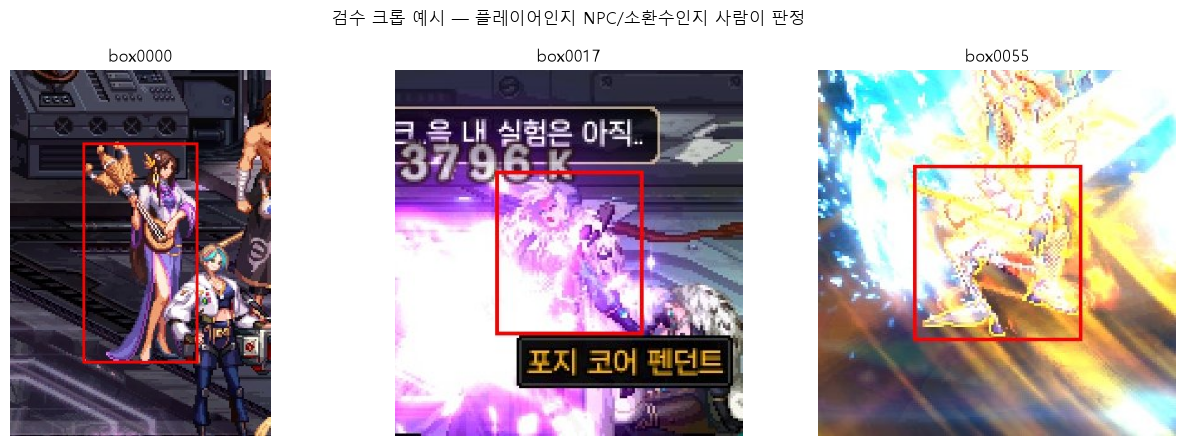

In [5]:
# 검수 대상 크롭 예시 (빨간 박스 = 라벨에 없는 character 탐지)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, bid in zip(axes, ["box0000", "box0017", "box0055"]):
    p = ROOT / "review" / "crops" / f"{bid}.jpg"
    if p.exists():
        ax.imshow(Image.open(p))
    ax.set_title(bid); ax.axis("off")
plt.suptitle("검수 크롭 예시 — 플레이어인지 NPC/소환수인지 사람이 판정")
plt.tight_layout(); plt.show()

## 3. 검수(Human Review) 진행 방식

212개 후보 박스를 효율적으로 판정하기 위해 **클릭 검수용 로컬 웹페이지**(`review/review.html`)를 생성했다:

- 박스마다 주변 맥락 80px을 포함한 크롭 카드 + **O(캐릭터) / X(아님) / ?(애매)** 3버튼
- 판정 기준: **"닉네임을 달 수 있는 플레이어 캐릭터인가?"**
- localStorage 자동 저장, 완료 후 CSV 내보내기

`?` 판정 8건은 350px 광역 맥락으로 다시 렌더링해 **닉네임 유무**를 근거로 재판정했다 (3건 O — 이펙트에 가려졌지만 닉네임 확인 / 5건 X — 보스 대사 출력 몬스터, 소환수, 부정확한 박스 등).

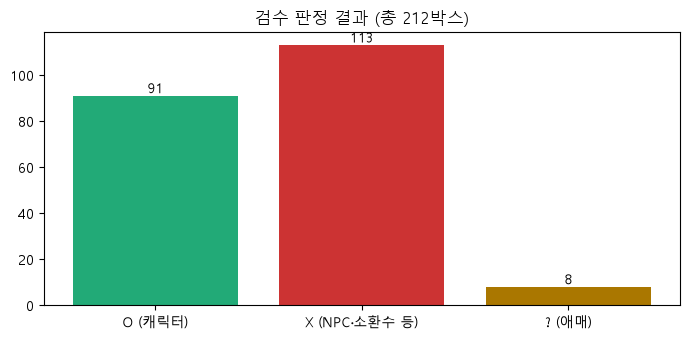

최종 라벨 반영: O 91 + ?재판정 3 = 94개 박스를 79개 JSON에 추가
X 113개(NPC·몬스터·소환수)는 라벨 미추가 -> 하드 네거티브로 오탐 억제에 활용


In [6]:
# 검수 판정 분포
rev = pd.read_csv(ROOT / "review" / "review_result.csv", encoding="utf-8-sig")
counts = rev["verdict"].value_counts()
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(["O (캐릭터)", "X (NPC·소환수 등)", "? (애매)"],
              [counts.get("O", 0), counts.get("X", 0), counts.get("?", 0)],
              color=["#2a7", "#c33", "#a70"])
ax.bar_label(bars)
ax.set_title(f"검수 판정 결과 (총 {len(rev)}박스)")
plt.tight_layout(); plt.show()
print("최종 라벨 반영: O 91 + ?재판정 3 = 94개 박스를 79개 JSON에 추가")
print("X 113개(NPC·몬스터·소환수)는 라벨 미추가 -> 하드 네거티브로 오탐 억제에 활용")

## 4. v2 재학습 결과 — v1 대비 비교

검수 반영 라벨로 데이터셋을 재구축(동일 seed 42 → 동일 train/val 분할)하고 합성 2,000장도 재생성한 뒤, 동일 설정으로 처음부터 재학습했다. v2는 51 epochs에서 조기 종료했다 (best: epoch 45).

> **공정성 참고**: val의 정답 라벨 자체도 v2에서 더 완전해졌다(인스턴스 223 → 236). 즉 v1 수치는 "불완전한 정답지"로 채점된 값인데, 그 채점 오차가 바로 라벨 노이즈의 실측 크기다.

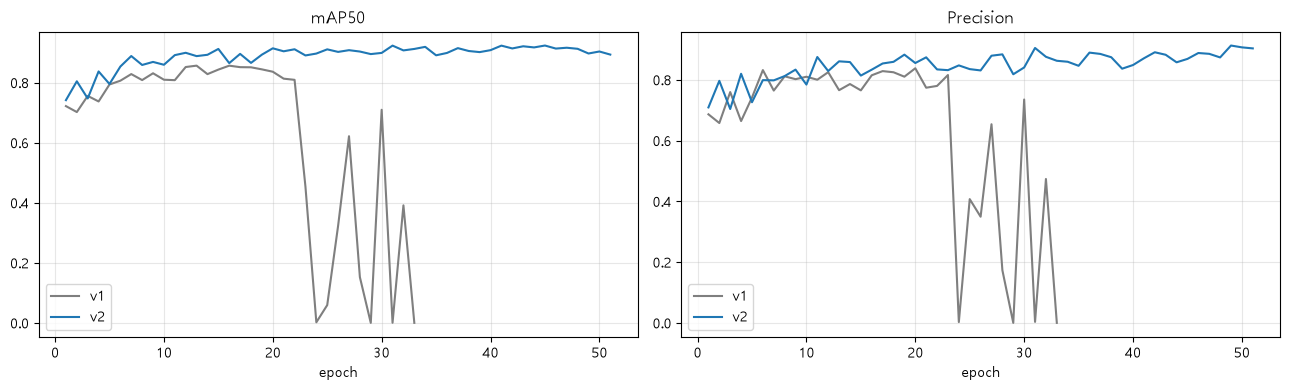

In [7]:
# v1 vs v2 학습 곡선 비교
v2_df = pd.read_csv(V2 / "results.csv")
v2_df.columns = v2_df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(v1_df["epoch"], v1_df["metrics/mAP50(B)"], label="v1", color="tab:gray")
axes[0].plot(v2_df["epoch"], v2_df["metrics/mAP50(B)"], label="v2", color="tab:blue")
axes[0].set_title("mAP50"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(v1_df["epoch"], v1_df["metrics/precision(B)"], label="v1", color="tab:gray")
axes[1].plot(v2_df["epoch"], v2_df["metrics/precision(B)"], label="v2", color="tab:blue")
axes[1].set_title("Precision"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

v1                               v2                         \
          Precision Recall  mAP50 mAP50-95 Precision Recall  mAP50 mAP50-95   
전체            0.763  0.865  0.856    0.535     0.904  0.838  0.923    0.602   
character     0.683  0.868  0.814    0.472     0.923  0.827  0.914    0.551   
user_id       0.844  0.862  0.897    0.598     0.885  0.849  0.933    0.652   

          Δ (v2-v1)                         
          Precision Recall  mAP50 mAP50-95  
전체            0.141 -0.027  0.067    0.067  
character     0.240 -0.041  0.100    0.079  
user_id       0.041 -0.013  0.036    0.054

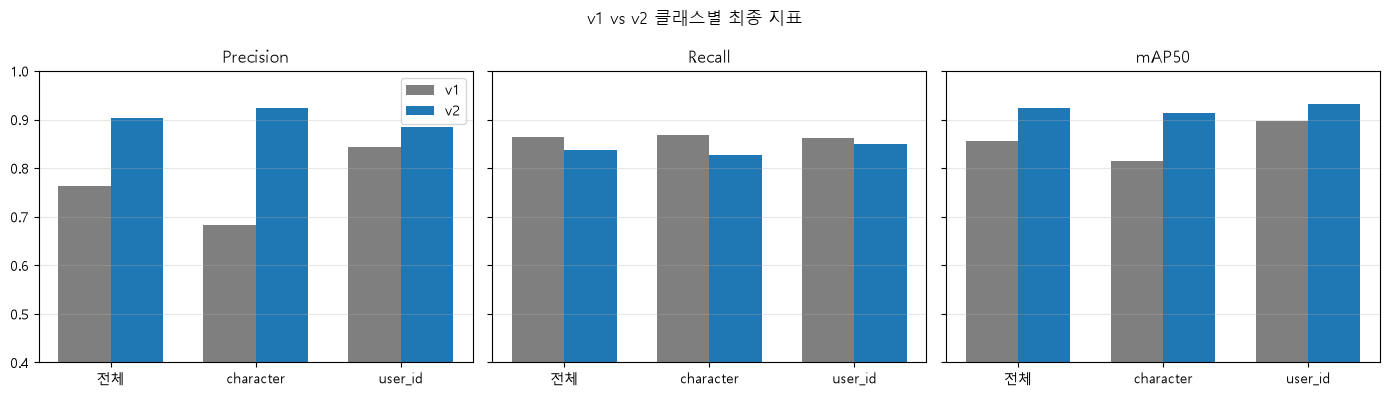

In [8]:
# 클래스별 최종 지표 비교 (각 run 종료 시 best.pt 검증 로그 값)
v2_final = pd.DataFrame({
    "Precision": [0.904, 0.923, 0.885],
    "Recall":    [0.838, 0.827, 0.849],
    "mAP50":     [0.923, 0.914, 0.933],
    "mAP50-95":  [0.602, 0.551, 0.652],
}, index=["전체", "character", "user_id"])

delta = (v2_final - v1_final).round(3)
comp = pd.concat({"v1": v1_final, "v2": v2_final, "Δ (v2-v1)": delta}, axis=1)
display(comp)

metrics = ["Precision", "Recall", "mAP50"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
x = range(3)
for ax, m in zip(axes, metrics):
    ax.bar([i - 0.18 for i in x], v1_final[m], width=0.36, label="v1", color="tab:gray")
    ax.bar([i + 0.18 for i in x], v2_final[m], width=0.36, label="v2", color="tab:blue")
    ax.set_xticks(list(x)); ax.set_xticklabels(v1_final.index)
    ax.set_title(m); ax.set_ylim(0.4, 1.0); ax.grid(axis="y", alpha=.3)
axes[0].legend()
plt.suptitle("v1 vs v2 클래스별 최종 지표")
plt.tight_layout(); plt.show()

## 5. 결론

| 항목 | 내용 |
|---|---|
| **가장 큰 개선** | character Precision **0.683 → 0.923 (+0.240)** — 미라벨 파티원 94박스를 라벨에 추가하고, NPC·소환수 113건을 하드 네거티브로 분리한 효과 |
| **character mAP50** | 0.814 → 0.914 (+0.100) |
| **user_id mAP50** | 0.897 → 0.933 (+0.036) — imgsz=1280 유지 덕분에 처음부터 안정적 |
| **전체 mAP50** | 0.856 → **0.923** (+0.067) |
| **비용** | 추가 라벨링 수작업 약 10~20분 (클릭 검수 212회) + 재학습 47분 |

**핵심 교훈**: 모델 성능의 병목은 모델·하이퍼파라미터가 아니라 **라벨 일관성**이었다. "학습된 모델로 자기 데이터를 재추론해 라벨 누락을 찾는" 감사 사이클은 적은 수작업으로 큰 개선을 얻는 효율적인 방법이었다.

### 향후 과제
1. **A안 후처리 추론 스크립트** — user_id 박스 바로 아래의 character를 "내 캐릭터"로 선정하는 최종 파이프라인
2. **2차 감사 사이클** — v2 모델로 한 번 더 audit하여 잔여 미라벨/오탐 정리 (수확 체감 예상, 선택적)
3. **배포 최적화** — 실시간 사용 시 ONNX/TensorRT 변환 (현재도 1.3ms/장으로 충분히 빠름)

### 산출물
- 최종 모델: `runs/df_yolo11s_1280_v2/weights/best.pt`
- 파이프라인: `scripts/convert_labelme.py` → `synthesize.py` → `train.py` → `audit_unlabeled.py` → `make_review.py` → `apply_review.py`
- 라벨 백업: `labeled_json_backup_20260612.zip` (검수 반영 전 원본)